In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("<your path for final dataset>", sep=None, engine="python")

pip(3) install xgboost

In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

y = df["is_alarm"]
X = df.drop(["is_alarm"], axis=1)
X = X.select_dtypes(include=[np.number])  

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]

print(xgb.__version__)

2.1.4


In [3]:
X.columns

Index(['day_datetimeEpoch', 'day_tempmax', 'day_tempmin', 'day_temp',
       'day_dew', 'day_humidity', 'day_precip', 'day_precipcover',
       'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'day_moonphase',
       'hour_datetimeEpoch', 'hour_temp', 'hour_humidity', 'hour_dew',
       'hour_precip', 'hour_precipprob', 'hour_snow', 'hour_snowdepth',
       'hour_windgust', 'hour_windspeed', 'hour_winddir', 'hour_pressure',
       'hour_visibility', 'hour_cloudcover', 'hour_solarradiation',
       'hour_solarenergy', 'hour_uvindex', 'region_id'],
      dtype='object')

SMOTE

pip(3) install imblearn

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

is_alarm
0.0    20980
1.0    20980
Name: count, dtype: int64


In [5]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report

y_resampled = y_resampled.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

#CPU
model = xgb.XGBClassifier(
    tree_method='hist',     
    predictor='cpu_predictor', 
    use_label_encoder=False,  
    eval_metric='logloss',  
    random_state=42
)


param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.8, 1.0, 1.2]
}

# RandomizedSearchCV with CPU
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    n_jobs=-1,     
    cv=3,
    verbose=2,
    error_score='raise' 
)

random_search.fit(X_train, y_train)
                  
y_pred = random_search.best_estimator_.predict(X_test)


print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [20:00:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4120
           1       0.98      0.99      0.98      4272

    accuracy                           0.98      8392
   macro avg       0.98      0.98      0.98      8392
weighted avg       0.98      0.98      0.98      8392


In [6]:
import joblib

joblib.dump(random_search.best_estimator_, 'XGB_F.pkl')

['XGB_F.pkl']

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

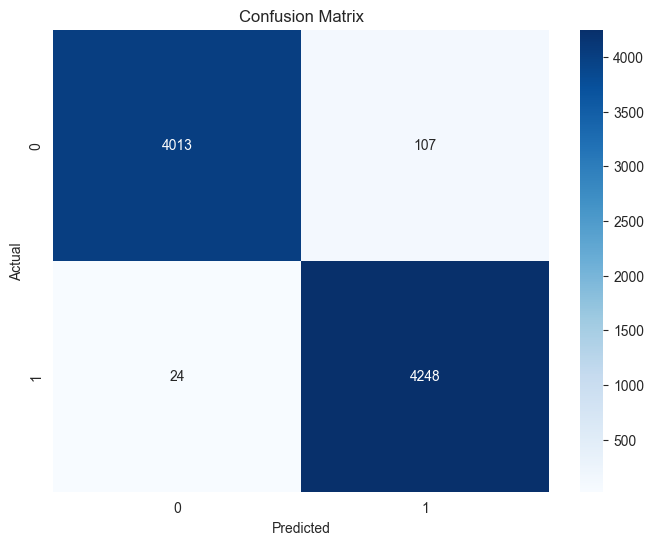

In [8]:
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

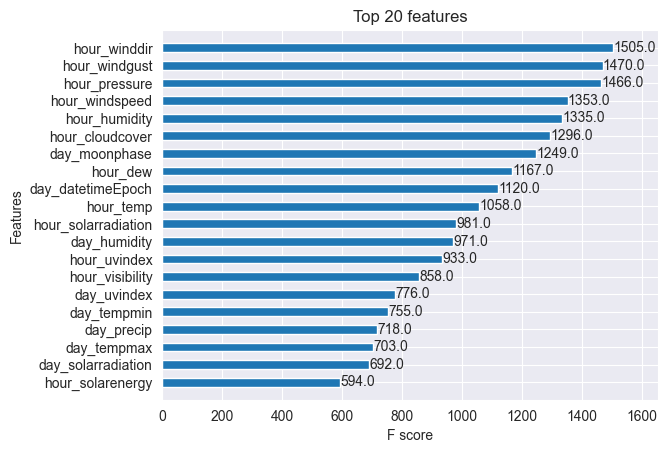

In [9]:
best_model = random_search.best_estimator_
xgb.plot_importance(best_model, importance_type='weight', max_num_features=20, height=0.5)
plt.title("Top 20 features")
plt.show()